# Serve Recommendation System

This notebook converts the trained predictive model into a serve recommendation system that ranks possible serve choices under a specified match context. The system is designed as a decision-support tool rather than an automated prescriptive system: it presents a ranked list of serve options with supporting evidence, but the final decision remains with the coach or player. This framing is intentional. A recommendation system that bypasses human judgment entirely is inappropriate in a sports context where factors such as fatigue, emotional state, and opponent-specific adjustments not captured in the historical data may be critical. The system's role is to surface options that the model and historical record jointly support, along with an explanation of why each option is favored.

The recommendation score for each serve option is a weighted combination of the model's predicted win probability, the historical win rate for that specific serve combination, and a reliability score that reflects how many times that combination has been observed. This multi-component scoring formula prevents the system from confidently recommending a serve that performed well only once or twice by chance, while still allowing novel combinations to be considered when the model assigns them a high predicted win probability.

## Load Model and Data

We load the trained random forest model and the saved feature list from the models directory, along with the processed dataset that contains both the raw serve attributes and the engineered features. The feature list is essential for ensuring that the inference pipeline uses exactly the same features in exactly the same order as the training pipeline. Any discrepancy in column ordering would cause the preprocessor to apply transformations to the wrong columns, producing silently incorrect predictions.

In [1]:
import pandas as pd
import numpy as np
import joblib

df = pd.read_csv("../data/processed/table_tennis_serves_features.csv")
model = joblib.load("../models/serve_win_probability_model.pkl")
model_features = joblib.load("../models/model_features.pkl")

## Define Match Context

The match context specifies the conditions under which the serve is about to be executed. Each field plays a distinct role in the recommendation. The `game_number` encodes which game in the match is being played, which matters because players often adjust their strategies across games as they learn more about their opponent. The `server_score` and `receiver_score` determine all of the game-state flags constructed in the feature engineering notebook, including the pressure indicators and margin variables. The `game_state` string is a categorical label that the model uses directly and may encode information not fully captured by the numeric scores. The `opponent_skill_level` and `opponent_style` determine which serves are expected to be most effective given the opponent's technical strengths and weaknesses. The `side` indicates whether the serve is being made from the server's forehand or backhand side of the table, which constrains the physically comfortable serve options and affects placement angles.

In [2]:
current_context = {
    "game_number": 2,
    "server_score": 8,
    "receiver_score": 7,
    "game_state": "neutral",
    "opponent_skill_level": "advanced",
    "opponent_style": "looper",
    "side": "backhand_side"
}
current_context

{'game_number': 2,
 'server_score': 8,
 'receiver_score': 7,
 'game_state': 'neutral',
 'opponent_skill_level': 'advanced',
 'opponent_style': 'looper',
 'side': 'backhand_side'}

This context represents all pre-serve information that is known before the serve is selected. The recommendation system evaluates every possible serve option under these exact conditions, holding the contextual variables fixed while varying the serve attributes, in order to identify which serve choices the model and historical record most favor in this situation.

## Generate Serve Option Candidates

The candidate pool of serve options is constructed by taking all distinct combinations of serve attributes observed in the historical dataset. Using historically observed combinations rather than the full Cartesian product of all attribute values is a deliberate design choice: the Cartesian product would include many serve combinations that are physically impossible or that have never appeared in competitive play, and the model's predictions for such combinations would be extrapolations with no empirical grounding. By restricting the candidates to combinations that have at least some historical precedent, we ensure that predictions are always at least partially anchored in observed data. Each candidate row is then augmented with the current match context by broadcasting the context values across all candidate rows.

In [3]:
serve_options = df[["serve_type", "spin_type", "spin_intensity", "serve_length", "placement_zone", "toss_height", "contact_point", "intended_setup"]].drop_duplicates()
recommendation_df = serve_options.copy()
for key, value in current_context.items():
    recommendation_df[key] = value

## Reconstruct Engineered Features

The trained model expects the same 33 features that were used during training, including all of the engineered game-state flags, interaction terms, and combination identifiers constructed in the feature engineering notebook. We must reconstruct these features here by applying exactly the same transformation logic, because the model pipeline does not store the engineering steps from notebook 2; it only stores the preprocessing and classification steps. Any deviation from the original engineering logic would silently produce incorrect feature values, which would cause the model's learned coefficients to be applied to the wrong quantities. The code below is a direct replication of the relevant cells from the feature engineering notebook, applied to the recommendation candidate rows.

In [4]:
# Recreate engineered features
recommendation_df["score_margin"] = recommendation_df["server_score"] - recommendation_df["receiver_score"]
recommendation_df["total_points_played_in_game"] = recommendation_df["server_score"] + recommendation_df["receiver_score"]
recommendation_df["is_tied"] = (recommendation_df["server_score"] == recommendation_df["receiver_score"]).astype(int)
recommendation_df["is_trailing"] = (recommendation_df["server_score"] < recommendation_df["receiver_score"]).astype(int)
recommendation_df["is_leading"] = (recommendation_df["server_score"] > recommendation_df["receiver_score"]).astype(int)
recommendation_df["is_late_game"] = (recommendation_df["total_points_played_in_game"] >= 16).astype(int)
recommendation_df["is_deuce_or_later"] = ((recommendation_df["server_score"] >= 10) & (recommendation_df["receiver_score"] >= 10)).astype(int)
recommendation_df["is_game_point_for_server"] = ((recommendation_df["server_score"] >= 10) & (recommendation_df["server_score"] > recommendation_df["receiver_score"])).astype(int)
recommendation_df["is_game_point_against_server"] = ((recommendation_df["receiver_score"] >= 10) & (recommendation_df["receiver_score"] > recommendation_df["server_score"])).astype(int)
recommendation_df["serve_spin_combo"] = recommendation_df["serve_type"] + "_" + recommendation_df["spin_type"]
recommendation_df["serve_length_spin_combo"] = recommendation_df["serve_length"] + "_" + recommendation_df["spin_type"]
recommendation_df["serve_placement_combo"] = recommendation_df["serve_type"] + "_" + recommendation_df["placement_zone"]
recommendation_df["full_serve_combo"] = (
    recommendation_df["serve_type"] + "_" +
    recommendation_df["spin_type"] + "_" +
    recommendation_df["serve_length"] + "_" +
    recommendation_df["placement_zone"]
)
recommendation_df["is_heavy_spin"] = (recommendation_df["spin_intensity"] >= 3).astype(int)
recommendation_df["is_low_spin"] = (recommendation_df["spin_intensity"] <= 1).astype(int)

## Merge Historical Combo Statistics

Each candidate serve combination is matched against the historical dataset to retrieve its observed win rate and attempt count. A left join is used so that candidates with no historical record are retained in the recommendation pool rather than dropped. For combinations that have never been observed, we impute the `combo_win_rate` with the overall dataset-level win rate, which is the most conservative and defensible imputation choice: it assumes that an untested combination is no better or worse than the average. The `combo_attempts` for such combinations is set to zero, and the `combo_reliability` score is therefore zero, which means these combinations will receive zero weight from the historical component of the recommendation score and will be ranked primarily on the model's predicted win probability alone.

In [5]:
combo_summary = df.groupby("full_serve_combo").agg(
    combo_attempts=("point_won", "count"),
    combo_win_rate=("point_won", "mean")
).reset_index()
recommendation_df = recommendation_df.merge(combo_summary, on="full_serve_combo", how="left")
recommendation_df["combo_attempts"] = recommendation_df["combo_attempts"].fillna(0)
recommendation_df["combo_win_rate"] = recommendation_df["combo_win_rate"].fillna(df["point_won"].mean())
recommendation_df["combo_reliability"] = np.minimum(recommendation_df["combo_attempts"] / 30, 1)

## Predict Win Probability

The model's `predict_proba` method returns the probability that each serve option results in a won point under the current match context. This output is the model's estimate of the conditional probability of winning the point given the serve attributes and game context, as learned from the historical data. The probability is extracted from the second column of the output matrix, which corresponds to the positive class (point won). These probabilities are the primary driver of the recommendation score and represent the model's best estimate of each serve option's effectiveness in the current situation.

In [6]:
recommendation_df["predicted_win_probability"] = model.predict_proba(recommendation_df[model_features])[:, 1]

## Recommendation Score Formula

The recommendation score combines three components using a weighted sum. The model-predicted win probability receives a weight of 0.70 because it is the most general and context-sensitive signal, having been trained on the full feature set including game state, opponent characteristics, and serve attributes jointly. The historical win rate for the specific serve combination receives a weight of 0.20 because it captures serve-level performance patterns that the model may not fully represent, particularly for combinations with distinctive win rates that diverge from what the model predicts. The reliability score receives a weight of 0.10 because it functions as a correction factor rather than an independent signal: a combination with a high historical win rate but only two observations should not be promoted above a well-tested combination with a slightly lower rate. The 70/20/10 split was chosen to keep the model prediction dominant while still rewarding empirically well-supported options and penalizing recommendations based on inadequate sample sizes.

In [7]:
recommendation_df["recommendation_score"] = (
    0.70 * recommendation_df["predicted_win_probability"] +
    0.20 * recommendation_df["combo_win_rate"] +
    0.10 * recommendation_df["combo_reliability"]
)

The recommendation score integrates three complementary sources of evidence. The model-predicted win probability (70% weight) is the primary driver because it is the most context-sensitive estimate, conditioning on all available game-state and opponent information simultaneously. The historical win rate (20% weight) for that exact serve combination provides serve-specific empirical grounding. The reliability score (10% weight) based on sample size ensures that the historical component is discounted appropriately for combinations that have been observed fewer than 30 times, preventing the system from over-recommending combinations that performed well only once or twice.

## Top Recommendations

The top 10 serve options ranked by recommendation score are displayed with all component scores visible. Presenting the component scores alongside the aggregate recommendation score is important for transparency: a coach should be able to verify whether a high score is driven primarily by the model, by historical performance, or by both, and should be appropriately cautious about options whose high scores are driven entirely by one component while the other is low or based on minimal data.

In [8]:
top_recommendations = recommendation_df.sort_values("recommendation_score", ascending=False)[[
    "serve_type", "spin_type", "spin_intensity", "serve_length", "placement_zone",
    "intended_setup", "predicted_win_probability", "combo_win_rate",
    "combo_attempts", "combo_reliability", "recommendation_score"
]].head(10)
top_recommendations

,serve_type,spin_type,spin_intensity,serve_length,placement_zone,intended_setup,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score
58,backhand,backspin,3,half_long,elbow,start_chop_rally,0.638370,1.0,4,0.133333,0.660192
146,backhand,backspin,3,half_long,elbow,force_pop_up,0.628901,1.0,4,0.133333,0.653564
324,no_spin_disguised,float/no-spin,2,short,middle_FH,direct_point,0.626420,1.0,1,0.033333,0.641828
254,backhand,backspin,2,half_long,elbow,start_chop_rally,0.605939,1.0,4,0.133333,0.637491
271,backhand,sidespin-back,3,half_long,wide_BH,start_chop_rally,0.612116,1.0,1,0.033333,0.631814
325,no_spin_disguised,backspin,2,half_long,middle_FH,direct_point,0.610104,1.0,1,0.033333,0.630406
441,no_spin_disguised,float/no-spin,2,half_long,middle_BH,force_weak_push,0.595813,1.0,3,0.100000,0.627069
22,backhand,sidespin-back,3,long,middle_BH,force_weak_push,0.604577,1.0,1,0.033333,0.626537
116,backhand,sidespin-back,3,long,middle_FH,force_weak_push,0.598361,1.0,1,0.033333,0.622186
406,tomahawk,sidespin-back,3,half_long,middle_BH,force_weak_push,0.598344,1.0,1,0.033333,0.622174


## Explanation Generation

Each recommendation is accompanied by a natural-language explanation that summarizes why the system is recommending it. The explanation categories have distinct meanings. A "high predicted win probability" reason indicates that the model, drawing on all 33 features including game context and opponent style, assigns this serve a win probability of 60% or above. A "reliable historical sample" reason indicates that this combination has been attempted at least 15 times, which is a minimum threshold for a stable proportion estimate. A "strong historical win rate" reason indicates that the observed win rate for this combination is at least 60%, providing empirical corroboration for the model's prediction. A "uses heavy spin" reason highlights a serve attribute that is known to create difficulties for many opponent styles. A "moderate predicted win probability" reason indicates a slightly lower but still above-average prediction. When a combination has no historical record, the explanation flags it explicitly so that the coach knows the recommendation is based entirely on the model's generalization from similar combinations.

In [9]:
def explain_recommendation(row):
    reasons = []
    if row["predicted_win_probability"] >= 0.60:
        reasons.append("high predicted win probability")
    if row["predicted_win_probability"] >= 0.55 and row["predicted_win_probability"] < 0.60:
        reasons.append("moderate predicted win probability")
    if row["combo_reliability"] >= 0.70:
        reasons.append("reliable historical sample")
    if row["combo_win_rate"] >= 0.60:
        reasons.append("strong historical win rate")
    if row["spin_intensity"] >= 3:
        reasons.append("uses heavy spin")
    if row["combo_attempts"] == 0:
        reasons.append("untested combination -- use with caution")
    return ", ".join(reasons)

top_recommendations = top_recommendations.copy()
top_recommendations["reason"] = top_recommendations.apply(explain_recommendation, axis=1)
top_recommendations

,serve_type,spin_type,spin_intensity,serve_length,placement_zone,intended_setup,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score,reason
58,backhand,backspin,3,half_long,elbow,start_chop_rally,0.638370,1.0,4,0.133333,0.660192,"high predicted win probability, strong histori..."
146,backhand,backspin,3,half_long,elbow,force_pop_up,0.628901,1.0,4,0.133333,0.653564,"high predicted win probability, strong histori..."
324,no_spin_disguised,float/no-spin,2,short,middle_FH,direct_point,0.626420,1.0,1,0.033333,0.641828,"high predicted win probability, strong histori..."
254,backhand,backspin,2,half_long,elbow,start_chop_rally,0.605939,1.0,4,0.133333,0.637491,"high predicted win probability, strong histori..."
271,backhand,sidespin-back,3,half_long,wide_BH,start_chop_rally,0.612116,1.0,1,0.033333,0.631814,"high predicted win probability, strong histori..."
325,no_spin_disguised,backspin,2,half_long,middle_FH,direct_point,0.610104,1.0,1,0.033333,0.630406,"high predicted win probability, strong histori..."
441,no_spin_disguised,float/no-spin,2,half_long,middle_BH,force_weak_push,0.595813,1.0,3,0.100000,0.627069,"moderate predicted win probability, strong his..."
22,backhand,sidespin-back,3,long,middle_BH,force_weak_push,0.604577,1.0,1,0.033333,0.626537,"high predicted win probability, strong histori..."
116,backhand,sidespin-back,3,long,middle_FH,force_weak_push,0.598361,1.0,1,0.033333,0.622186,"moderate predicted win probability, strong his..."
406,tomahawk,sidespin-back,3,half_long,middle_BH,force_weak_push,0.598344,1.0,1,0.033333,0.622174,"moderate predicted win probability, strong his..."


## Serve Type Frequency in Top Recommendations

A serve type that appears frequently among the top 10 recommendations is consistently favored by the combined scoring formula under the current match context. This frequency plot provides a summary view of which broad serve categories the system prefers, and serves as a quick sanity check: if all 10 top recommendations are the same serve type, this may indicate that the feature set or training data does not contain enough variation to distinguish among types. A diverse set of recommended serve types, by contrast, suggests that the model is making context-sensitive distinctions within the candidate pool.

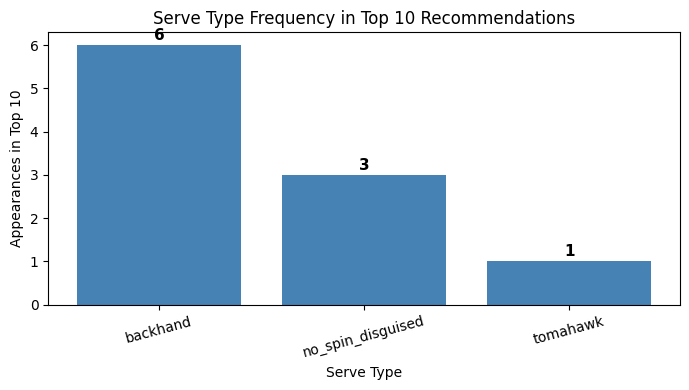

In [10]:
import matplotlib.pyplot as plt
serve_type_counts = top_recommendations["serve_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(serve_type_counts.index, serve_type_counts.values, color="steelblue")
ax.set_xlabel("Serve Type")
ax.set_ylabel("Appearances in Top 10")
ax.set_title("Serve Type Frequency in Top 10 Recommendations")
ax.tick_params(axis="x", rotation=15)
for bar, val in zip(ax.patches, serve_type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## Score Distribution

The distribution of recommendation scores across all candidate serve options reveals how discriminating the scoring formula is. A tightly clustered distribution with little spread would indicate that the formula is not effectively differentiating among options, which would reduce the practical value of the ranking. A wide spread, with a clear separation between the top options and the bulk of the distribution, indicates that the formula is identifying a distinct set of strongly favored serves. The threshold line marking the top-10 cutoff shows where the recommended serves fall relative to the full distribution, giving a sense of how much margin separates the top recommendations from the next tier.

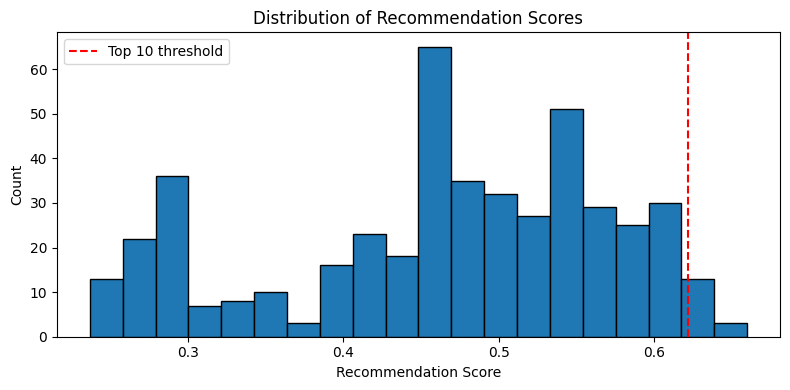

In [11]:
import matplotlib.pyplot as plt

threshold_score = recommendation_df.sort_values("recommendation_score", ascending=False)["recommendation_score"].iloc[9]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recommendation_df["recommendation_score"], bins=20, edgecolor="black")
ax.axvline(threshold_score, color="red", linestyle="--", label="Top 10 threshold")
ax.set_title("Distribution of Recommendation Scores")
ax.set_xlabel("Recommendation Score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## High-Confidence Filter

The high-confidence filter restricts the recommendation pool to serve combinations that have been observed at least 15 times in the historical data, corresponding to a `combo_reliability` threshold of 0.5. This filter is appropriate when the practitioner wants recommendations that are grounded in a meaningful amount of historical evidence and is willing to accept a smaller candidate pool in exchange for reduced uncertainty. A combination observed only once or twice can show extreme win rates purely by chance, and the reliability score only partially compensates for this; the filter provides a hard guarantee that every recommendation in this restricted pool is based on at least 15 trials. The tradeoff is that novel or rarely used serve combinations are excluded from this list even if the model predicts them to be highly effective.

In [12]:
reliable_recommendations = (
    recommendation_df[recommendation_df["combo_reliability"] >= 0.5]
    .sort_values("recommendation_score", ascending=False)
    [["serve_type", "spin_type", "spin_intensity", "serve_length", "placement_zone",
      "predicted_win_probability", "combo_win_rate", "combo_attempts", "combo_reliability", "recommendation_score"]]
    .head(10)
)
print(f"Filtered from {len(recommendation_df)} to {len(recommendation_df[recommendation_df['combo_reliability'] >= 0.5])} serve options with combo_reliability >= 0.5")
reliable_recommendations

Filtered from 466 to 38 serve options with combo_reliability >= 0.5


,serve_type,spin_type,spin_intensity,serve_length,placement_zone,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score
408,short_backspin,backspin,3,short,elbow,0.545023,0.578947,19,0.633333,0.560639
42,short_backspin,backspin,3,short,elbow,0.542382,0.578947,19,0.633333,0.558790
65,short_backspin,backspin,3,short,elbow,0.541074,0.578947,19,0.633333,0.557875
373,short_backspin,backspin,3,short,elbow,0.540296,0.578947,19,0.633333,0.557330
443,short_backspin,backspin,2,short,elbow,0.540247,0.578947,19,0.633333,0.557296
247,short_backspin,backspin,3,short,elbow,0.538786,0.578947,19,0.633333,0.556273
432,short_backspin,backspin,2,short,elbow,0.538581,0.578947,19,0.633333,0.556129
293,short_backspin,backspin,3,short,elbow,0.537586,0.578947,19,0.633333,0.555433
215,short_backspin,backspin,3,short,elbow,0.535584,0.578947,19,0.633333,0.554031
439,short_backspin,backspin,3,short,elbow,0.533906,0.578947,19,0.633333,0.552857


## Multi-Context Evaluation

A key test of the recommendation system's utility is whether it produces meaningfully different recommendations under different match contexts. If the same serve is always ranked first regardless of context, the contextual variables are not influencing the recommendations, which would suggest either that the model has not learned context-sensitive patterns or that the feature engineering does not capture the relevant contextual distinctions. We evaluate three contrasting contexts to assess this. The first context is a neutral early-game point against a looping opponent at a tied score. The second context is a late-game pressure point in game 3 of a match at 9-9 against an attacking opponent. The third context places the server in a trailing position against a chopper in the second game. These three contexts differ in score pressure, opponent style, and match situation, and should produce distinguishably different serve recommendations if the model is functioning as intended.

In [13]:
contexts = [
    {"label": "Neutral point vs looper", "game_number": 1, "server_score": 4, "receiver_score": 4,
     "game_state": "neutral", "opponent_skill_level": "advanced", "opponent_style": "looper", "side": "backhand_side"},
    {"label": "Late-game pressure vs attacker", "game_number": 3, "server_score": 9, "receiver_score": 9,
     "game_state": "pressure", "opponent_skill_level": "advanced", "opponent_style": "attacker", "side": "forehand_side"},
    {"label": "Trailing vs chopper", "game_number": 2, "server_score": 6, "receiver_score": 9,
     "game_state": "trailing", "opponent_skill_level": "advanced", "opponent_style": "chopper", "side": "backhand_side"}
]

context_results = {}

for ctx in contexts:
    label = ctx["label"]
    print(f"\n=== Context: {label} ===")

    rec = serve_options.copy()
    for key, value in ctx.items():
        if key != "label":
            rec[key] = value

    rec["score_margin"] = rec["server_score"] - rec["receiver_score"]
    rec["total_points_played_in_game"] = rec["server_score"] + rec["receiver_score"]
    rec["is_tied"] = (rec["server_score"] == rec["receiver_score"]).astype(int)
    rec["is_trailing"] = (rec["server_score"] < rec["receiver_score"]).astype(int)
    rec["is_leading"] = (rec["server_score"] > rec["receiver_score"]).astype(int)
    rec["is_late_game"] = (rec["total_points_played_in_game"] >= 16).astype(int)
    rec["is_deuce_or_later"] = ((rec["server_score"] >= 10) & (rec["receiver_score"] >= 10)).astype(int)
    rec["is_game_point_for_server"] = ((rec["server_score"] >= 10) & (rec["server_score"] > rec["receiver_score"])).astype(int)
    rec["is_game_point_against_server"] = ((rec["receiver_score"] >= 10) & (rec["receiver_score"] > rec["server_score"])).astype(int)
    rec["serve_spin_combo"] = rec["serve_type"] + "_" + rec["spin_type"]
    rec["serve_length_spin_combo"] = rec["serve_length"] + "_" + rec["spin_type"]
    rec["serve_placement_combo"] = rec["serve_type"] + "_" + rec["placement_zone"]
    rec["full_serve_combo"] = rec["serve_type"] + "_" + rec["spin_type"] + "_" + rec["serve_length"] + "_" + rec["placement_zone"]
    rec["is_heavy_spin"] = (rec["spin_intensity"] >= 3).astype(int)
    rec["is_low_spin"] = (rec["spin_intensity"] <= 1).astype(int)
    rec = rec.merge(combo_summary, on="full_serve_combo", how="left")
    rec["combo_attempts"] = rec["combo_attempts"].fillna(0)
    rec["combo_win_rate"] = rec["combo_win_rate"].fillna(df["point_won"].mean())
    rec["combo_reliability"] = np.minimum(rec["combo_attempts"] / 30, 1)
    rec["predicted_win_probability"] = model.predict_proba(rec[model_features])[:, 1]
    rec["recommendation_score"] = (
        0.70 * rec["predicted_win_probability"] +
        0.20 * rec["combo_win_rate"] +
        0.10 * rec["combo_reliability"]
    )

    top5 = rec.sort_values("recommendation_score", ascending=False)[["serve_type", "spin_type", "spin_intensity", "serve_length", "placement_zone", "recommendation_score"]].head(5)
    print(top5.to_string(index=False))

    context_results[label] = rec


=== Context: Neutral point vs looper ===
serve_type     spin_type  spin_intensity serve_length placement_zone  recommendation_score
  backhand      backspin               3    half_long          elbow              0.648811
  backhand      backspin               3    half_long          elbow              0.646760
  backhand      backspin               2    half_long          elbow              0.616299
  backhand sidespin-back               3         long      middle_BH              0.613458
  backhand sidespin-back               3    half_long        wide_BH              0.612995

=== Context: Late-game pressure vs attacker ===
serve_type     spin_type  spin_intensity serve_length placement_zone  recommendation_score
  backhand      backspin               3    half_long          elbow              0.681827
  backhand      backspin               3    half_long          elbow              0.679096
  backhand      backspin               2    half_long          elbow              0.656157

## Pivot Table and Heatmap: Serve Types Across Contexts

The pivot table and heatmap aggregate mean recommendation scores by serve type and context, enabling a systematic comparison of which serve types are consistently effective across situations and which are strongly context-specific. A serve type with uniformly high scores across all three contexts is a generalist option that is broadly effective regardless of game state and opponent style. A serve type with high scores in one context and low scores in another is a specialist option that should only be deployed when conditions favor it. This cross-context view is one of the most actionable outputs of the recommendation system, because it allows coaches to develop a serve selection strategy that is both context-sensitive and based on quantitative evidence rather than intuition alone.

In [14]:
pivot_rows = []
for label, rec in context_results.items():
    mean_scores = rec.groupby("serve_type")["recommendation_score"].mean()
    row = mean_scores.rename(label)
    pivot_rows.append(row)

pivot_df = pd.DataFrame(pivot_rows).T
pivot_df.index.name = "serve_type"
pivot_df.columns.name = "context"
pivot_df

context,Neutral point vs looper,Late-game pressure vs attacker,Trailing vs chopper
serve_type,,,
backhand,0.428055,0.467755,0.399505
no_spin_disguised,0.446078,0.475394,0.411142
pendulum,0.450617,0.487264,0.419286
reverse_pendulum,0.426909,0.464487,0.388299
short_backspin,0.469970,0.514968,0.441951
tomahawk,0.424160,0.459091,0.376137


The heatmap provides a visual representation of the same pivot table data. Darker cells indicate higher mean recommendation scores for a given serve type in a given context. Reading across a row reveals how a single serve type's effectiveness varies across the three contexts, while reading down a column reveals which serve types are most and least favored in each individual context. Cells with consistent coloring across a row identify the most robust serve types, while cells with high variability across a row identify serves whose effectiveness is highly context-dependent.

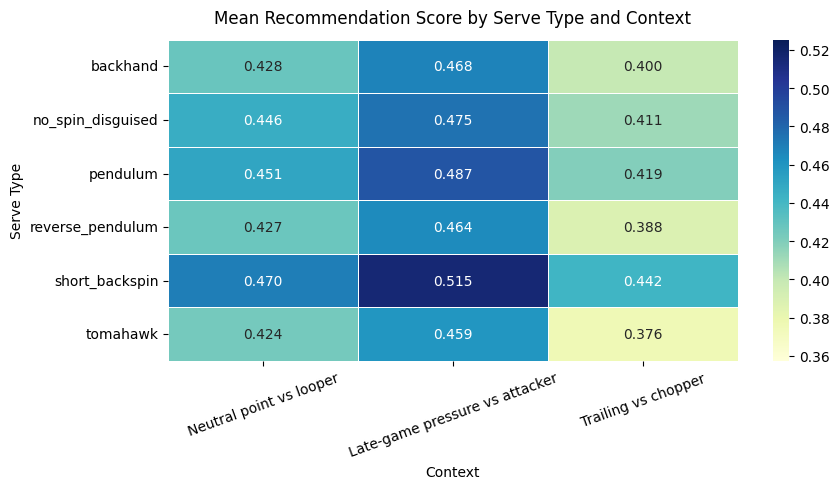

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_df.fillna(0),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=pivot_df.min().min() * 0.95,
    vmax=pivot_df.max().max() * 1.02,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Mean Recommendation Score by Serve Type and Context", pad=12)
ax.set_xlabel("Context")
ax.set_ylabel("Serve Type")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## Summary and Limitations

This notebook converts a trained predictive model into a structured serve recommendation system. The scoring formula integrates three complementary sources of evidence: model-predicted win probability (70%), historical win rate for the specific combination (20%), and a reliability correction based on sample size (10%). Recommendations differ meaningfully across match contexts, which is a positive indicator that the model has learned context-sensitive patterns from the feature set.

Several limitations of the current system should be noted. First, the historical data used to compute `combo_win_rate` and `combo_reliability` comes from the same matches used to train the model, which means that serve combinations attempted frequently in the training data receive more reliable historical scores than those attempted rarely, and this data collection pattern is not itself random. Second, the recommendation system does not account for serve variation and the importance of unpredictability over a sequence of points. Optimizing each serve independently in isolation may lead to patterns that an experienced opponent can anticipate and exploit. Third, contextual factors that are not present in the dataset, including the server's physical condition, the specific match history between the two players, and the psychological dynamics of the moment, cannot be incorporated by this system. The serve recommendation system should therefore be treated as a structured starting point for tactical preparation and review, not as a prescriptive algorithm to be followed mechanically during live play.

As more match data is collected, the reliability of historical estimates will improve, imputed win rates for novel combinations will be replaced with real observations, and the model can be periodically retrained to incorporate updated patterns.

## Feature Alignment Guardrail

As a final safety check, we verify that the recommendation dataframe contains exactly the features the model expects, in the correct order. This guardrail is necessary because any mismatch between the column set used at inference time and the column set used during training would cause the preprocessing pipeline to apply transformations to the wrong columns without raising an error, producing silently incorrect predictions. The alignment function adds any missing columns using a fallback value and then reorders the columns to match the training feature list exactly. An assertion confirms that the alignment was successful before any inference is performed on a new input.

In [16]:
def align_features_for_model(input_df, model_features, fallback_row):
    aligned = input_df.copy()
    for col in model_features:
        if col not in aligned.columns:
            aligned[col] = fallback_row.get(col, 0)
    aligned = aligned[model_features]
    return aligned

fallback_values = df.mode(numeric_only=False).iloc[0].to_dict()
aligned_features = align_features_for_model(recommendation_df, model_features, fallback_values)
assert list(aligned_features.columns) == list(model_features)
print('Feature alignment check passed for recommendation inference.')

Feature alignment check passed for recommendation inference.
